# 3. The Source Reconstruction Workflow


<div class="alert alert-success">
    <b>Goal of this notebook</b>:
     <ul>
      <li>Understand the workflow of a source reconstruction analysis and what kind of data it requires.</li>
      <li>Understand what the forward model represents.</li>
    </ul>
</div>


Below you can find a schematic overview of the entire source reconstruction pipeline. In this tutorial we will focus only on the computation of the inverse model. 

We precomputed: 
- BEM Layer: segmenting T1 scan into scalp, skull and brain
- Coregistration (using freesurfer)
- The Forward Model Computation - producing a matrix called the lead field matrix, gain matrix or simply forward model


![Workflow](img/sourcerec_workflow.png)

How the MNE Python documentation describes the workflow: 

Red: Structural data (MRI),
Blue: Electrophysiological data (EEG/MEG)

![mne_workflow](img/mne_workflow.png)


## 3.1 What is the forward model?

An EEG electrode records activity not only from a single brain region underneath the sensor. Every sensor sees a weighted sum of the activity of the *whole* cortex, because current spreads through brain, skull and scalp. With the forward model we try to find out how neural source could smear onto the electrode measurements, given the participant anatomy and EEG cap position. 

Therefore, the forward model only depends on **geometry and conductivity**, which is the source space (which we obtained via a T1 MRI scan), the BEM head model and the electrode positions (digitization), but not on the measured data!! The result of the forward model computation is the so called lead field $\mathbf{L}$. Often you will see both term used interchangebly. 

It is computed once from the head model and the source space, and inside MNE's forward-solution object it is a plain array you can inspect:

`fwd['sol']['data']` → shape `(n_channels, n_sources)`

With *free* orientations each source point carries three orthogonal dipoles, so $\mathbf{L}$ becomes $N \times 3M$ and $\mathbf{x}$ stacks the $(x, y, z)$ components per location. With *fixed* orientations (dipoles clamped normal to the cortical surface) it is $N \times M$ again.

**Read $\mathbf{L}$ column by column.** Column $k$ is the scalp topography produced by a unit-strength dipole at source point $k$. So the lead field is a dictionary of topographies, one per candidate source, and the forward model just says: *the measurement is a weighted sum of these topographies.*

In [1]:
# load precomputed forward model
import os
import mne
import numpy as np
import matplotlib.pyplot as plt

# data paths - everything for this participant shares one prefix
subID = 24
data_path = "data"
subject_path = os.path.join(f"sub-0{subID}", "ses-mecha", "eeg")
base = os.path.join("..", data_path, subject_path, f"sub-0{subID}_ses-mecha_task-NT_")

fwd = mne.read_forward_solution(base + "fwd.fif")

# the lead field itself: (n_channels, n_sources)
print("lead field shape:", fwd["sol"]["data"].shape)
print("source orientation:", fwd["source_ori"])

Reading forward solution from /data/tu_grossmannr/Conferences/CuttingEEG2026/cuttingeeg-2026-sourcerec-tutorial/notebooks/../data/sub-024/ses-mecha/eeg/sub-024_ses-mecha_task-NT_fwd.fif...
    Reading a source space...
    [done]
    Reading a source space...
    [done]
    2 source spaces read
    Desired named matrix (kind = 3523 (FIFF_MNE_FORWARD_SOLUTION_GRAD)) not available
    Read EEG forward solution (20484 sources, 62 channels, fixed orientations)
    Source spaces transformed to the forward solution coordinate frame
lead field shape: (62, 20484)
source orientation: 1 (FIFFV_MNE_FIXED_ORI)


## 3.2 Leadfield visualization

To understand better what the leadfield is, we will pick a column (representing the leadfield columns of one source) and plot the topography. 

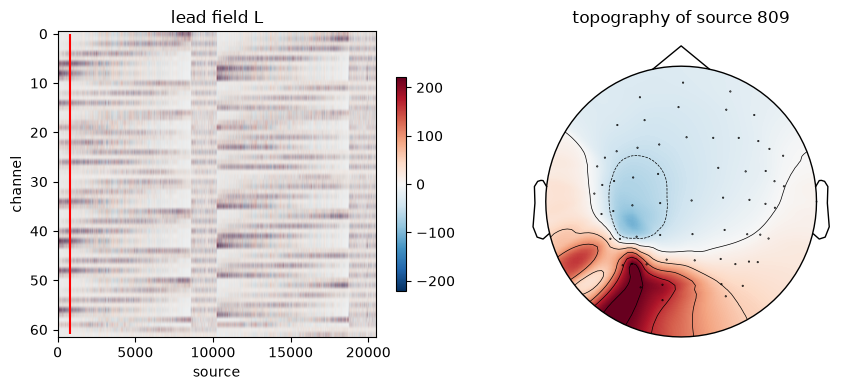

In [24]:
# visualize the lead field matrix: 
# every column is the scalp topography of one source
source = 809 # should be below 20484

leadfield = fwd["sol"]["data"]
picks_eeg = mne.pick_types(fwd["info"], meg=False, eeg=True)

fig, axes = plt.subplots(1, 2, figsize=(9, 4))

vmax = np.percentile(np.abs(leadfield), 99)
im = axes[0].imshow(leadfield[picks_eeg], aspect="auto", cmap="RdBu_r",
                     vmin=-vmax, vmax=vmax)
axes[0].vlines(x=source, ymin=0, ymax=picks_eeg.shape[0] - 1, colors='r')
axes[0].set_xlabel("source")
axes[0].set_ylabel("channel")
axes[0].set_title("lead field L")
fig.colorbar(im, ax=axes[0], shrink=0.7)

# plot the scalp topography
mne.viz.plot_topomap(leadfield[picks_eeg, source], fwd["info"], axes=axes[1], show=False)
axes[1].set_title(f"topography of source {source}")

fig.tight_layout()

The red stripe indicates which source you selected to plot. Sorting of the vertices:
occipital to frontal per hemisphere (higher vertices -> more frontal). Two stripes show vertices scattered over the whole hemisphere, they are leftovers from FreeSurfer's topology correction, the ordering is not by neighbouring columns.  

<div class="alert alert-warning">
    <b>Exercise</b>:
    Experiment with different sources and plot their topography.
     <ul>
      <li>What types of topographies do you observe?</li>
      <li>Why do the leadfield columns of the sources differ? Give at least 3 reasons.</li>
    </ul>
</div>

## 3.3 The Problem: Leadfield columns are non-unique!

We have 62 channels in our measurement and ~20000 source vertices of which we want to reconstuct the activity. This means that many of the source vertices produce the same output on sensor level. To see this in our leadfield matrix we can simply compute the rank of the matrix. 

In [28]:
M = leadfield.shape[1]
rank = np.linalg.matrix_rank(leadfield)

nullity = M - rank

print("Number of sources:", M)
print("Rank:", rank)
print("Null-space dimension:", nullity)

Number of sources: 20484
Rank: 62
Null-space dimension: 20422
